In [ ]:
import time
from datetime import datetime
import numpy as np
from uldaq import (
    get_daq_device_inventory, DaqDevice, InterfaceType,   # <-- InterfaceType 추가
    AiInputMode, Range,
    ScanOption, AInScanFlag, ScanStatus,
    create_float_buffer       
)
import os 
import re

def format_freq_khz(freq_khz):
    """
    파일명용 주파수 문자열 생성.
    예:
    25     -> r25k
    32.8   -> r32k8
    0      -> r0
    """
    if freq_khz == 0:
        return "r0"

    if float(freq_khz).is_integer():
        return f"r{int(freq_khz)}k"
    else:
        freq_str = str(freq_khz).replace(".", "k")
        return f"r{freq_str}"

def get_next_filename(path, base_name):
    """
    같은 파일명이 있으면 _01, _02, ... 식으로 증가
    """
    i = 1
    while os.path.exists(os.path.join(path, f"{base_name}_{i:02d}.bin")):
        i += 1
    return f"{base_name}_{i:02d}"

# -------------------------
# 사용자 설정
# -------------------------
CHAN = [0]                    # 수집할 AI 채널
INPUT_MODE = AiInputMode.SINGLE_ENDED  # 필요 시 DIFF로 변경
AI_RANGE = Range.BIP10VOLTS # 기기 레인지에 맞게
RATE_REQ = 8_000          # 200 kS/s
DURATION_S = 10
TARGET_SAMPLES = RATE_REQ * DURATION_S *len(CHAN)  # 15M samples
BUF_SAMPLES = 40000000       # UL 내부/호스트 전송 버퍼 크기(1채널 기준) ~0.4s worth
POLL_INTERVAL = 0.05        # 50 ms

# 실험 조건 설정(파일명 저장 목적)
RESONATOR_FREQ_KHZ = 25      # 예: 25, 32.8, 0
UNJAMMING_ON = True          # True면 uj1, False면 uj0

SAVE_DIR = "/home/jonghyuk/Desktop/micloaker/bin"

# filename = get_next_filename("/media/jonghyuk/T7 Shield/micloker/", "file")
# OUTFILE = f"/media/jonghyuk/T7 Shield/micloker/{filename}.bin"  # 순수 이진(double little-endian)

timestamp = datetime.now().strftime("%y%m%d-%H%M")

freq_tag = format_freq_khz(RESONATOR_FREQ_KHZ)
unjam_tag = "uj1" if UNJAMMING_ON else "uj0"

base_name = f"{timestamp}_{freq_tag}_{unjam_tag}"

filename = get_next_filename(SAVE_DIR, base_name)
OUTFILE = os.path.join(SAVE_DIR, f"{filename}.bin")

print(f"저장 파일명: {OUTFILE}")

#filename = get_next_filename("/home/jonghyuk/Desktop/", "file")
#OUTFILE = f"/home/jonghyuk/Desktop/{filename}.bin"  # 순수 이진(double little-endian)
#/home/jonghyuk/Desktop/

#OUTFILE = "touch_off_on_touch.bin"
# -------------------------
# 장치 열기
# -------------------------
# 장치 검색: 반드시 interface_type 지정
descriptors = get_daq_device_inventory(InterfaceType.USB)

if not descriptors:
    raise RuntimeError("No MCC USB DAQ devices found. Is the USB-1608G connected and permissions OK?")

daq_dev = DaqDevice(descriptors[0])
daq_dev.connect()


ai_dev = daq_dev.get_ai_device()

# 순환 버퍼 생성 (double precision)
data_buf = create_float_buffer(1, BUF_SAMPLES)

# 백그라운드 연속 스캔 시작
actual_rate = ai_dev.a_in_scan(
    CHAN[0],
    CHAN[0],
    INPUT_MODE,
    AI_RANGE,
    BUF_SAMPLES,
    RATE_REQ,
    ScanOption.CONTINUOUS | ScanOption.BLOCKIO,
    AInScanFlag.DEFAULT,          # Volt 단위 스케일 & 캘 적용.
    data_buf
)
print(f"Actual HW rate: {actual_rate} S/s")

# numpy view로 캐스팅
np_buf = np.ctypeslib.as_array(data_buf)  # shape (BUF_SAMPLES,)

# 파일 열기 (버퍼링 최소화)
f = open(OUTFILE, "wb", buffering=0)

# 진행 상태
last_total = 0
written = 0

try:
    while written < TARGET_SAMPLES:
        status, xfer = ai_dev.get_scan_status()
        if status == ScanStatus.RUNNING:
            total = xfer.current_total_count  # 전체 전송된 샘플 수(채널 인터리브 반영; 1채널이면 그대로)
            delta = total - last_total
            if delta > 0:
                # 현재 인덱스(0-based)까지 데이터가 유효
                idx = xfer.current_index  # 현재 작성 위치
                # 새로 전송된 delta 만큼의 샘플 범위를 계산 (순환 버퍼 래핑 처리)
                start = (idx - delta + BUF_SAMPLES) % BUF_SAMPLES
                if start < idx:  # 래핑 없음
                    chunk = np_buf[start:idx]
                    
                    f.write(chunk.tobytes())
                    written += chunk.size
                else:            # 래핑: 두 조각
                    chunk1 = np_buf[start:BUF_SAMPLES]
                    chunk2 = np_buf[0:idx]
                    f.write(chunk1.tobytes())
                    f.write(chunk2.tobytes())
                    written += chunk1.size + chunk2.size
                    
                last_total = total 
        else:
            print("Scan stopped unexpectedly.")
            break
        
        time.sleep(POLL_INTERVAL)
        

finally:
    # 스캔 종료 및 정리
    ai_dev.scan_stop()
    daq_dev.disconnect()
    daq_dev.release()
    f.close()



print(f"Wrote {written} samples ({written*8/1e6:.1f} MB) to {OUTFILE}")

KeyboardInterrupt: 

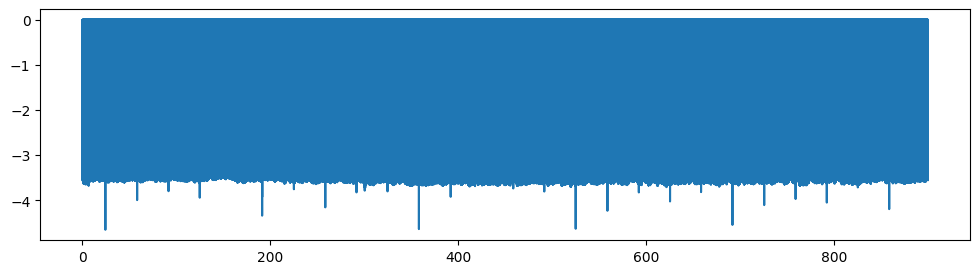

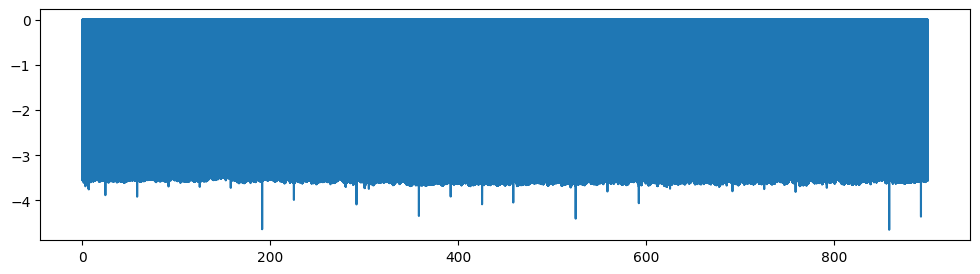

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# OUTFILE = "/media/cyphy/Hynix PSSD/250731/tooki/cyphy1.bin" 
data = np.fromfile(OUTFILE, dtype=np.float64)[100:-100]
data1 = data[::2]
data2 = data[1::2]
fs = 8_000



       

t = np.arange(data1.size, dtype=np.float64) / fs
plt.figure(figsize=(12,3))
plt.plot(t,-data1)
plt.show()

t = np.arange(data2.size, dtype=np.float64) / fs
plt.figure(figsize=(12,3))
plt.plot(t,-data2)
plt.show()


# t = np.arange(data2.size, dtype=np.float64) / fs
# plt.figure(figsize=(12,3))
# plt.plot(data2[:1000000])
# plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import spectrogram

# fs = 100_000

# # Compute the spectrogram
# f, t_spec, Sxx = spectrogram(data1, fs)

# # Plot the spectrogram
# plt.figure(figsize=(10, 5))
# plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud')  # dB scale
# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [sec]')
# plt.title('Spectrogram using scipy.signal.spectrogram')
# plt.colorbar(label='Power/Frequency (dB/Hz)')
# plt.tight_layout()
# plt.show()

# # Compute the spectrogram
# f, t_spec, Sxx = spectrogram(data2, fs)

# # Plot the spectrogram
# plt.figure(figsize=(10, 5))
# plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud')  # dB scale
# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [sec]')
# plt.title('Spectrogram using scipy.signal.spectrogram')
# plt.colorbar(label='Power/Frequency (dB/Hz)')
# plt.tight_layout()
# plt.show()
